# DSP — Audio Processing with Python

**Exercise 1.2 from Think DSP**

Download a sound sample from freesound.org, select a 0.5-second segment with a well-defined pitch, compute its spectrum, and apply high-pass, low-pass, and band-stop filters to explore how filtering changes the harmonic structure and timbre of the sound.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.io import wavfile as wav 
from scipy import signal


## Reading and Segmenting the Audio

We load the WAV file, extract the left channel, and select a 0.5-second segment starting at t=1s. The time-domain plot shows amplitude vs sample index — this is the raw waveform of the signal.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12912\2504418941.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs,data=wav.read("thinkdsp01.wav")


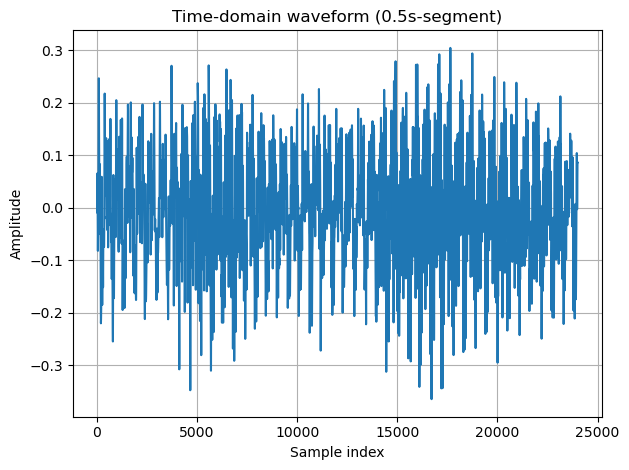

In [2]:
fs,data=wav.read("thinkdsp01.wav")

audio=data[:,0]
start=fs*1
end=start+int(0.5*fs) 
seg=audio[start:end]


plt.figure()
plt.title("Time-domain waveform (0.5s-segment)")
plt.plot(seg)
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# Spectrum of the Segment
We compute the real FFT of the 0.5s segment. np.fft.rfft returns only the positive frequency components (the spectrum of a real signal is symmetric, so this is sufficient). The y-axis shows magnitude 

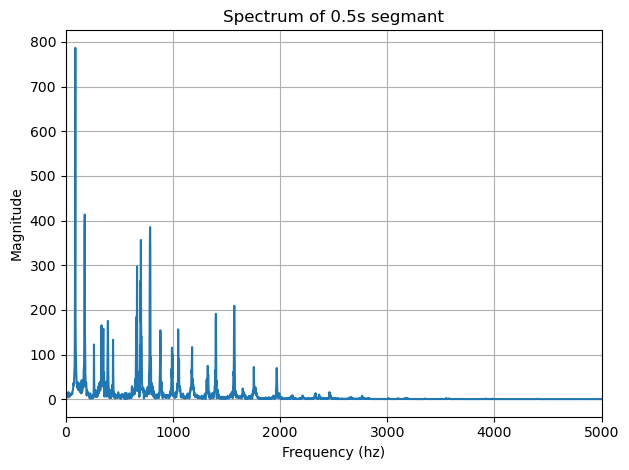

In [3]:
spectrum=np.fft.rfft(seg) 
fre=np.fft.rfftfreq(len(seg),1/fs)

# BUG FIX: spectrum is complex — must plot np.abs(spectrum), not spectrum directly
plt.plot(fre,abs(spectrum))
plt.title("Spectrum of 0.5s segmant")
plt.xlabel("Frequency (hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.xlim(0,5000)
plt.show()

# Low-pass Filter (cutoff = 1000 Hz)
A 4th-order Butterworth low-pass filter keeps frequencies below 1000 Hz and attenuates higher frequencies. Removing high-frequency harmonics makes the sound duller and less bright — like hearing it through a wall. The spectrum shows only the low-frequency components remain.

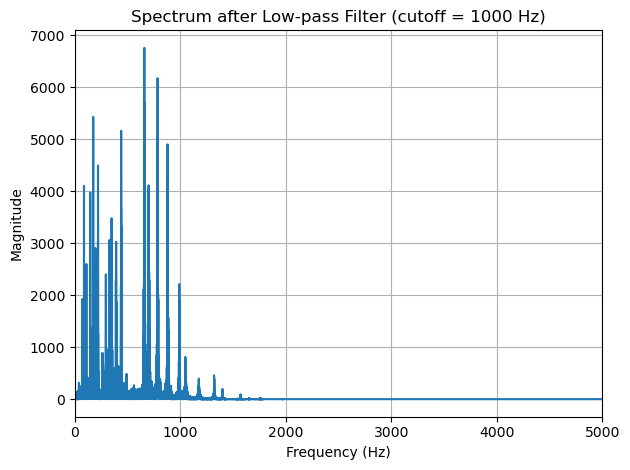

In [4]:
b,a=signal.butter(4,1000,btype='low',fs=fs)
low_si=signal.filtfilt(b,a,audio) 
low_sp=np.fft.rfft(low_si)
freq=np.fft.rfftfreq(len(low_si),1/fs)
plt.plot(freq,abs(low_sp))
plt.xlim(0,5000)
plt.title("Spectrum after Low-pass Filter (cutoff = 1000 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

low_fft=np.fft.rfft(low_si)
low_wave=np.fft.irfft(low_fft)
low_wave/=np.max(np.abs(low_wave))
wav.write("lowpass.wav",fs,(low_wave*32767).astype(np.int16))


# High-pass Filter (cutoff = 1000 Hz)¶
A 4th-order Butterworth high-pass filter keeps frequencies above 1000 Hz and attenuates lower ones. This removes the fundamental and low harmonics, leaving only the bright, thin, high-frequency content. The sound becomes tinny and loses its body.

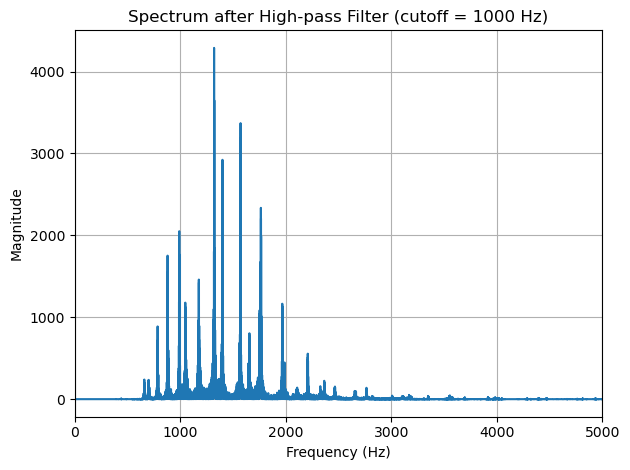

In [5]:
b,a=signal.butter(4,1000,btype='high',fs=fs)
high_si=signal.filtfilt(b,a,audio)
high_sp=np.fft.rfft(high_si)
freq=np.fft.rfftfreq(len(high_si),1/fs)
plt.plot(freq,abs(high_sp))
plt.xlim(0,5000)
plt.title("Spectrum after High-pass Filter (cutoff = 1000 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()
high_fft = np.fft.rfft(high_si)
high_wave = np.fft.irfft(high_fft)
high_wave/=np.max(np.abs(high_wave))
wav.write("highpass.wav",fs,(high_wave*32767).astype(np.int16))

# Band-stop Filter (800–1500 Hz)
A 4th-order Butterworth band-stop (notch) filter removes frequencies between 800 Hz and 1500 Hz while keeping frequencies outside that band. The sound loses harmonics in the mid-frequency range, creating a hollow or nasal character. The spectrum shows a clear dip in the 800–1500 Hz region.

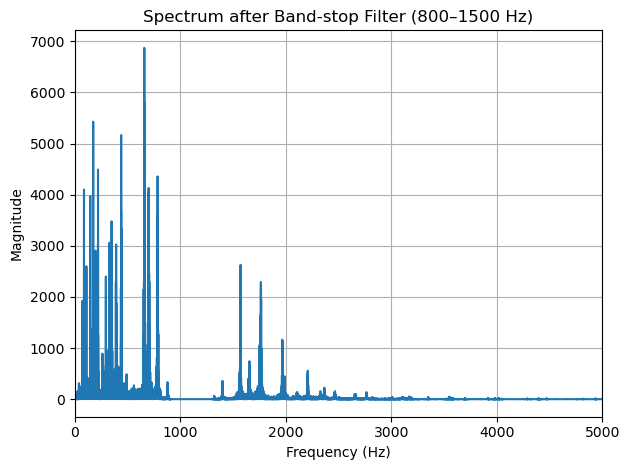

In [6]:
b,a=signal.butter(4,[800,1500],btype='bandstop',fs=fs)
bs_si=signal.filtfilt(b,a,audio)
bs_sp=np.fft.rfft(bs_si)
freq=np.fft.rfftfreq(len(bs_si),1/fs)
plt.plot(freq,abs(bs_sp))
plt.xlim(0,5000)
plt.title("Spectrum after Band-stop Filter (800–1500 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

bs_fft=np.fft.rfft(bs_si)
bs_wave=np.fft.irfft(bs_fft)
bs_wave/=np.max(np.abs(bs_wave))
wav.write("bandstop.wav",fs,(bs_wave*32767).astype(np.int16))